<a href="https://colab.research.google.com/github/Chase-Troy/Course-Assignments/blob/main/K_Means_Clustering_and_PCA_Analysis_on_Iris_and_MNIST_Datasets_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports and Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_iris, fetch_openml
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Make plots look cleaner
plt.style.use('seaborn-v0_8')

PART 1 — Elbow Method on Iris Dataset

In [6]:
iris = load_iris()
X_iris = iris.data

print("Dataset shape:", X_iris.shape)

Dataset shape: (150, 4)


Compute WCSS for Different k Values

In [7]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_iris)
    wcss.append(kmeans.inertia_)

print("WCSS values calculated")

WCSS values calculated


Plot the Elbow Curve

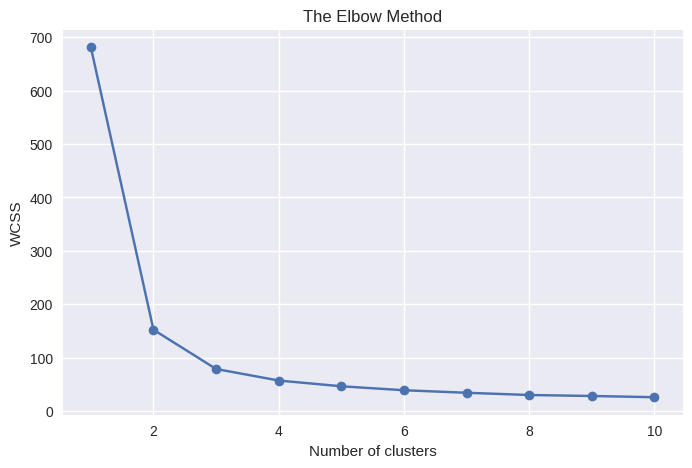

In [8]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("The Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

PART 2 — MNIST Logistic Regression WITHOUT PCA

In [9]:
# Load MNIST dataset

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

print("Dataset shape:", X.shape)

Dataset shape: (70000, 784)


Train/Test Split + Scaling

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaling complete")

Data scaling complete


Train Logistic Regression WITHOUT PCA

In [11]:
start_time = time.time()

log_reg = LogisticRegression(max_iter=1000, solver='lbfgs')
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)

end_time = time.time()

accuracy_no_pca = accuracy_score(y_test, y_pred)
time_no_pca = end_time - start_time

print("Accuracy without PCA:", accuracy_no_pca)
print("Training time without PCA:", time_no_pca, "seconds")

Accuracy without PCA: 0.9153571428571429
Training time without PCA: 39.26207137107849 seconds


PART 3 — MNIST Logistic Regression WITH PCA (0.95 Variance)

In [12]:
pca = PCA(0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original features:", X_train_scaled.shape[1])
print("Reduced features:", X_train_pca.shape[1])

Original features: 784
Reduced features: 330


Train Logistic Regression WITH PCA

In [13]:
start_time = time.time()

log_reg_pca = LogisticRegression(max_iter=1000, solver='lbfgs')
log_reg_pca.fit(X_train_pca, y_train)

y_pred_pca = log_reg_pca.predict(X_test_pca)

end_time = time.time()

accuracy_pca = accuracy_score(y_test, y_pred_pca)
time_pca = end_time - start_time

print("Accuracy with PCA:", accuracy_pca)
print("Training time with PCA:", time_pca, "seconds")

Accuracy with PCA: 0.922
Training time with PCA: 44.8375780582428 seconds


PART 4 — Results Comparison

In [14]:
results = pd.DataFrame({
    "Model": ["Without PCA", "With PCA"],
    "Accuracy": [accuracy_no_pca, accuracy_pca],
    "Training Time (s)": [time_no_pca, time_pca]
})

results

,Model,Accuracy,Training Time (s)
0,Without PCA,0.915357,39.262071
1,With PCA,0.922000,44.837578


Visualization

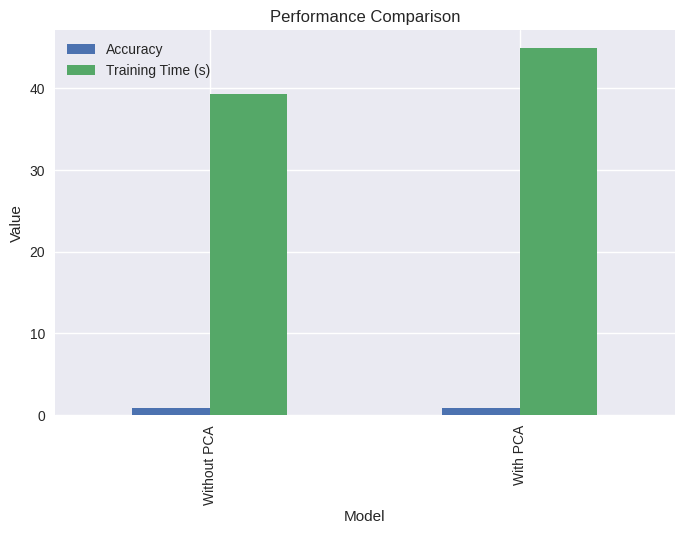

In [15]:
results.set_index("Model")[["Accuracy", "Training Time (s)"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Performance Comparison")
plt.ylabel("Value")
plt.show()